# Project Definition

This project analyzes a synthetic emergency room triage dataset to understand how patient vital signs, symptoms, and arrival conditions relate to triage urgency. The goal is to explore the data, clean it, and identify patterns that influence triage level assignment. This stage includes loading the dataset, assessing data quality, cleaning unnecessary or inconsistent fields, and performing exploratory data analysis (EDA) to understand the behavior of the emergency care ecosystem before building predictive models.

Group Members:
Talh Hossin ,  Hamed Almehdhar ,  Mohammad Almahi

In [1]:
import sys
!{sys.executable} -m pip install matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd

df = pd.read_csv("../data/synthetic_medical_triage.csv")

df.head()

,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode,triage_level (how urgent) 0 not really &3 very urgent,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,17.9,95.4,147.1,97.4,36.48,1,0,0,walk_in,0,NaN,NaN,NaN
1,79.2,147.9,158.6,96.0,39.35,10,4,2,ambulance,3,NaN,NaN,NaN
2,51.1,87.1,128.2,98.5,37.74,5,2,2,walk_in,1,NaN,NaN,NaN
3,56.8,84.7,147.2,92.5,37.55,4,4,4,walk_in,1,NaN,NaN,NaN
4,39.2,58.0,107.8,99.0,36.26,2,1,1,walk_in,0,NaN,NaN,NaN


# Data Exploration & Quality Assessment  
## Emergency Room Triage Prediction under Concept Drift

This notebook performs exploratory data analysis (EDA) and data quality assessment 
for the synthetic emergency room triage dataset.

The goal is to understand feature distributions, class balance, and potential 
data quality issues before model development.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/synthetic_medical_triage.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (18000, 13)


,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode,triage_level (how urgent) 0 not really &3 very urgent,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,17.9,95.4,147.1,97.4,36.48,1,0,0,walk_in,0,NaN,NaN,NaN
1,79.2,147.9,158.6,96.0,39.35,10,4,2,ambulance,3,NaN,NaN,NaN
2,51.1,87.1,128.2,98.5,37.74,5,2,2,walk_in,1,NaN,NaN,NaN
3,56.8,84.7,147.2,92.5,37.55,4,4,4,walk_in,1,NaN,NaN,NaN
4,39.2,58.0,107.8,99.0,36.26,2,1,1,walk_in,0,NaN,NaN,NaN


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 13 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   age                                                     18000 non-null  float64
 1   heart_rate                                              18000 non-null  float64
 2   systolic_blood_pressure                                 18000 non-null  float64
 3   oxygen_saturation                                       18000 non-null  float64
 4   body_temperature                                        18000 non-null  float64
 5   pain_level                                              18000 non-null  int64  
 6   chronic_disease_count                                   18000 non-null  int64  
 7   previous_er_visits                                      18000 non-null  int64  
 8   arrival_mode                                   

### Dataset Structure Summary

- The dataset contains **18,000 patient records**.
- There are **13 total columns**.
- Feature types include:
  - **7 numerical (float64)** variables representing physiological measurements.
  - **4 integer (int64)** variables representing discrete medical attributes.
  - **2 categorical (string)** variables.
- No missing values are observed in the main clinical variables.
- However, there are unnecessary columns (`Unnamed: 10`, `Unnamed: 11`, `Unnamed: 12`) which appear to be artifacts and will be removed during cleaning.

The dataset appears structurally complete and suitable for further preprocessing.

In [8]:
missing = df.isnull().sum()
missing[missing > 0]

Unnamed: 10    18000
Unnamed: 11    18000
Unnamed: 12    17999
dtype: int64

In [9]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [10]:
df = df.drop_duplicates()

In [11]:
df.rename(columns={
    'triage_level  (how urgent) 0 not really &3 very urgent': 'triage_level'
}, inplace=True)

The original column name for the target variable was long and difficult to use 
in modeling. It has been renamed to `triage_level` for clarity, readability, 
and consistency across notebooks.

triage_level
0    9924
1    4484
2    2701
3     891
Name: count, dtype: int64


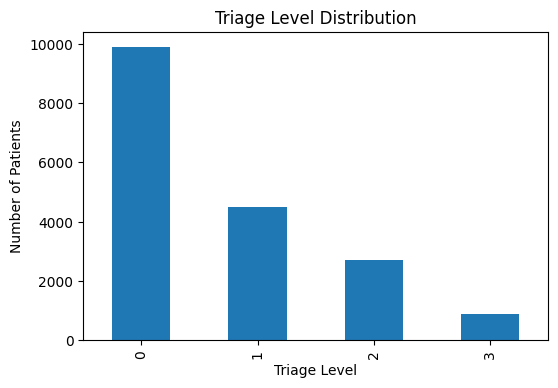

In [12]:
class_counts = df['triage_level'].value_counts()
print(class_counts)

plt.figure(figsize=(6,4))
class_counts.sort_index().plot(kind='bar')
plt.title("Triage Level Distribution")
plt.xlabel("Triage Level")
plt.ylabel("Number of Patients")
plt.show()

### Triage Level Distribution

- Level 0 is dominant.
- Level 3 is rare.
- The dataset is imbalanced.

Accuracy alone is not sufficient.  
We must use Precision, Recall, and F1-score during modeling.

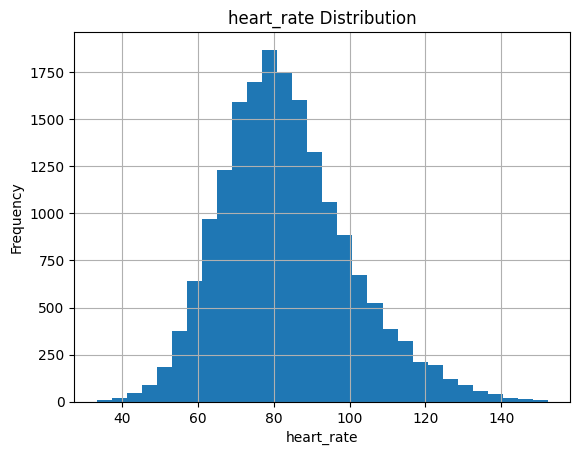

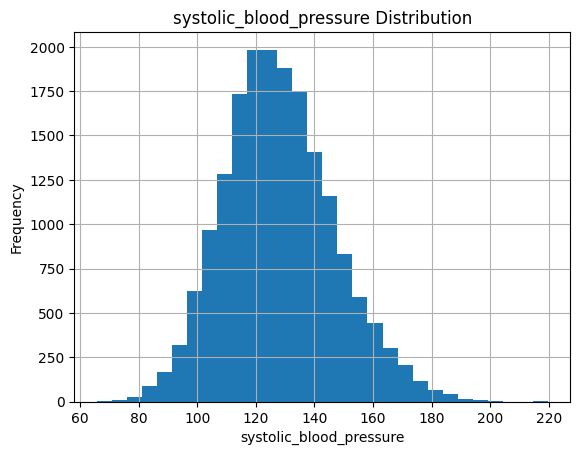

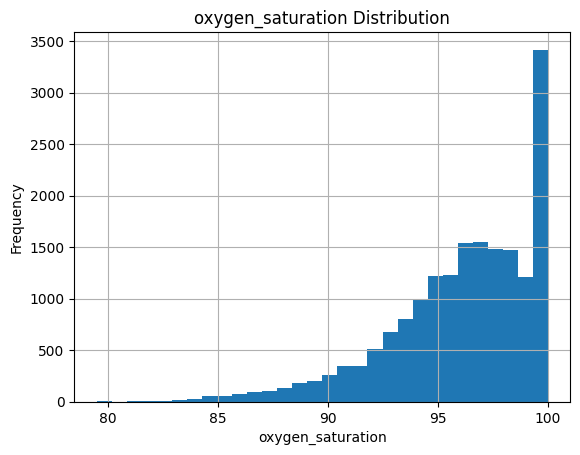

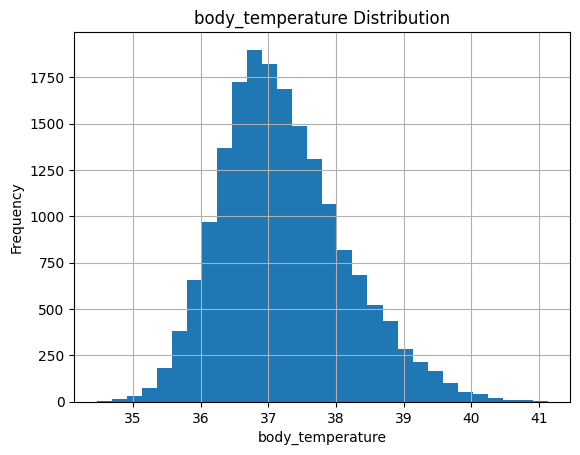

In [13]:
features = ['heart_rate', 'systolic_blood_pressure',
            'oxygen_saturation', 'body_temperature']

for feature in features:
    plt.figure()
    df[feature].hist(bins=30)
    plt.title(f"{feature} Distribution")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

### Vital Signs Distribution Analysis

- **Heart Rate**: Approximately normally distributed around 75–85 bpm. Some high values (>130 bpm) but still medically plausible in emergency cases.
  
- **Systolic Blood Pressure**: Roughly normal distribution centered around 120–130 mmHg. A few high values (>180) which may represent hypertensive emergencies.

- **Oxygen Saturation**: Slight left skew (many values close to 100%). Lower values (<90%) are present and clinically realistic for critical patients.

- **Body Temperature**: Approximately normal distribution centered around 37°C. Some elevated values (>39°C) consistent with fever cases.

### Conclusion
Vital signs appear medically realistic.  
Some mild skewness is observed (especially oxygen saturation), but no extreme unrealistic outliers are detected.

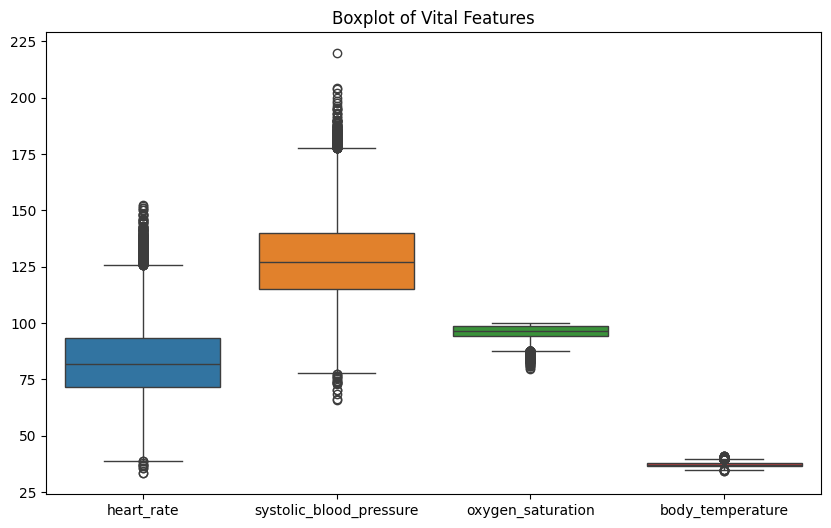

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[features])
plt.title("Boxplot of Vital Features")
plt.show()

### Extreme Vital Signs Analysis

The boxplot shows several extreme values:

- **Heart Rate**: Some values >140 bpm and <40 bpm. These are extreme but medically possible in severe emergency cases.
- **Systolic Blood Pressure**: Values >180 mmHg and some <80 mmHg. These may represent hypertensive crises or shock conditions.
- **Oxygen Saturation**: A few values <85%, which are clinically critical but realistic.
- **Body Temperature**: Some values >40°C, indicating severe fever but still plausible.

### Conclusion
Extreme values appear medically plausible and may represent critical emergency patients rather than data errors. Therefore, no outlier removal is performed at this stage.

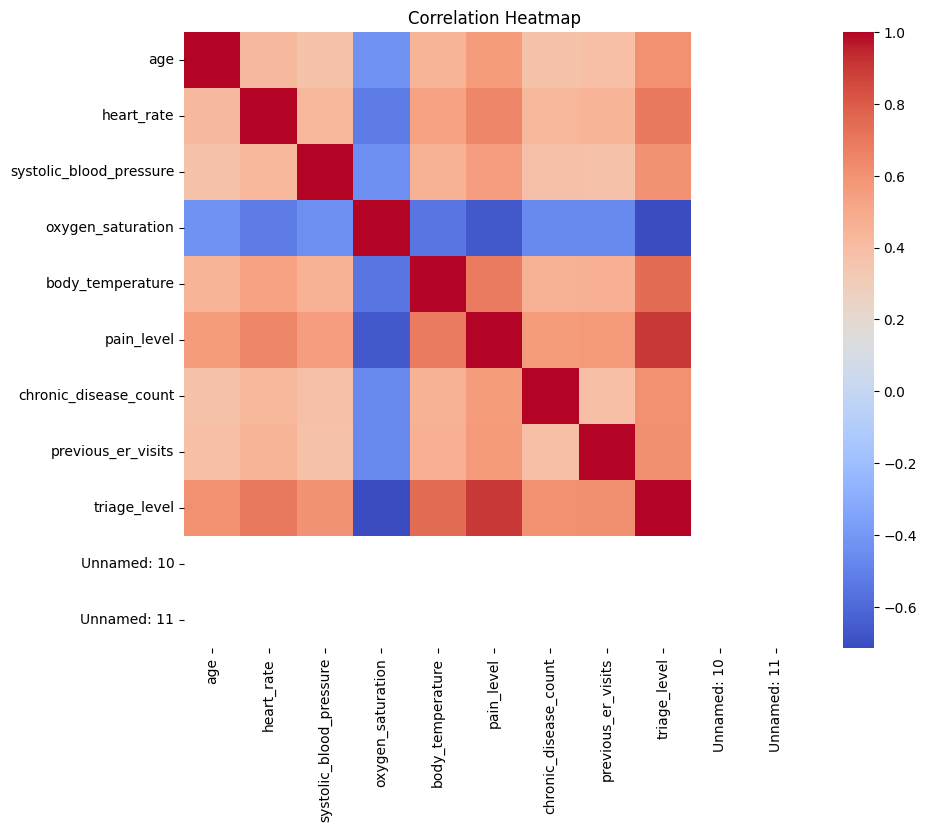

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis

- **Triage Level** shows moderate positive correlation with:
  - pain_level
  - heart_rate
  - body_temperature
  - systolic_blood_pressure

- **Oxygen Saturation** shows negative correlation with triage_level 
  (lower oxygen → higher urgency).

### Strong Predictors
Pain level and vital signs (heart rate, temperature, blood pressure) 
appear to be meaningful predictors of triage urgency.

### Multicollinearity
No extremely high correlations (>0.9) between features are observed, 
so severe multicollinearity is unlikely.

In [17]:
df.to_csv(("../data/synthetic_medical_triage.csv"), index=False)


print("Clean raw dataset saved.")

Clean raw dataset saved.


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.isnull().sum()

age                            0
heart_rate                     0
systolic_blood_pressure        0
oxygen_saturation              0
body_temperature               0
pain_level                     0
chronic_disease_count          0
previous_er_visits             0
arrival_mode                   0
triage_level                   0
Unnamed: 10                18000
Unnamed: 11                18000
Unnamed: 12                17999
dtype: int64

In [20]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [21]:
df.isnull().sum()
df.columns

Index(['age', 'heart_rate', 'systolic_blood_pressure', 'oxygen_saturation',
       'body_temperature', 'pain_level', 'chronic_disease_count',
       'previous_er_visits', 'arrival_mode', 'triage_level'],
      dtype='str')

### Final Data Cleaning

Empty and irrelevant columns ("Unnamed") were removed.

No missing values or duplicate records remain.

The dataset is now clean and ready for modeling.

## Summary of Findings

- Dataset contains 18,000 patient records.
- No significant missing values were detected.
- Class imbalance observed (majority: Triage Level 0).
- Vital signs show realistic medical distributions.
- Correlation analysis indicates moderate relationships between some physiological variables.

The dataset is now validated and ready for feature engineering and model development.